# Titanic Survival Prediction Using Logistic Regression

## Machine Learning Assignment



**Dataset:** Titanic Dataset from Kaggle
**Algorithm:** Logistic Regression
**Programming Language:** Python

## 1. Objective

The objective of this project is to build a Logistic Regression model
to predict whether a passenger survived the Titanic disaster.

The model uses passenger information such as passenger class, age,
number of siblings or spouses, and number of parents or children
to predict survival.

## 2. Introduction

The Titanic dataset contains information about passengers who were
on board the Titanic.

In this project, Logistic Regression is used to predict whether a
passenger survived or did not survive.

The target variable is Survived.

0 represents that the passenger did not survive.
1 represents that the passenger survived.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [2]:
df = pd.read_csv("train.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## 3. Dataset Description

The Titanic dataset contains information about passengers who were
on board the Titanic.

The dataset contains 891 passenger records and 12 columns.

The important columns used in this project are:

- Pclass – Passenger class
- Age – Passenger age
- SibSp – Number of siblings or spouses aboard
- Parch – Number of parents or children aboard
- Survived – Survival status

The target variable is Survived.

0 means the passenger did not survive.
1 means the passenger survived.

In [3]:
df.shape

(891, 12)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [5]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [6]:
df["Age"] = df["Age"].fillna(df["Age"].median())

In [7]:
X = df[["Pclass", "Age", "SibSp", "Parch"]]
y = df["Survived"]

In [8]:
print("Missing values in X:")
print(X.isnull().sum())

print("\nMissing values in y:")
print(y.isnull().sum())

Missing values in X:
Pclass    0
Age       0
SibSp     0
Parch     0
dtype: int64

Missing values in y:
0


In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (712, 4)
Testing data: (179, 4)


In [10]:
model = LogisticRegression()

In [11]:
model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

In [12]:
y_pred = model.predict(X_test)

print(y_pred[:10])

[0 0 0 1 0 1 0 0 0 1]


In [13]:
comparison = pd.DataFrame({
    "Actual Survival": y_test.values[:10],
    "Predicted Survival": y_pred[:10]
})

comparison

,Actual Survival,Predicted Survival
0,1,0
1,0,0
2,0,0
3,1,1
4,1,0
5,1,1
6,1,0
7,0,0
8,1,0
9,1,1


In [14]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.7430167597765364


In [15]:
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[94 11]
 [35 39]]


In [16]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.73      0.90      0.80       105
           1       0.78      0.53      0.63        74

    accuracy                           0.74       179
   macro avg       0.75      0.71      0.72       179
weighted avg       0.75      0.74      0.73       179



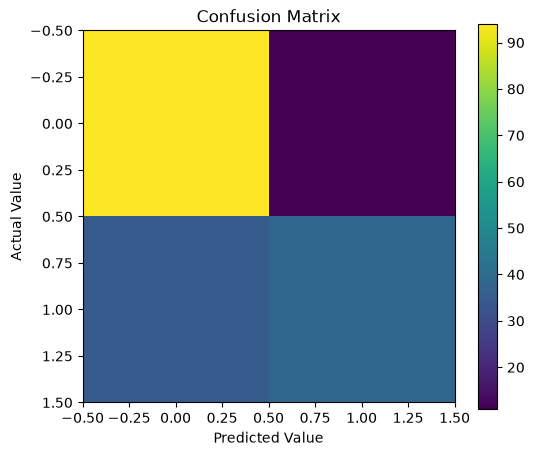

In [17]:
plt.figure(figsize=(6, 5))

plt.imshow(cm)

plt.xlabel("Predicted Value")
plt.ylabel("Actual Value")
plt.title("Confusion Matrix")

plt.colorbar()
plt.show()

In [18]:
print("Intercept:", model.intercept_)
print("Coefficients:", model.coef_)

Intercept: [2.69502738]
Coefficients: [[-0.98663756 -0.03227715 -0.21669111  0.26704568]]


## 7. Results Interpretation

The Logistic Regression model was evaluated using accuracy,
confusion matrix, precision, recall, and F1-score.

Accuracy shows the percentage of test cases that were predicted
correctly.

The confusion matrix shows the number of correct and incorrect
predictions for passengers who survived and passengers who did not
survive.

Precision shows how many of the passengers predicted as a particular
class actually belonged to that class.

Recall shows how many passengers from an actual class were correctly
identified by the model.

F1-score is a combined measure of precision and recall.

## 8. Conclusion

In this project, a Logistic Regression model was developed to predict
whether a passenger survived the Titanic disaster.

The model used Pclass, Age, SibSp, and Parch as input features and
Survived as the target variable.

The dataset was preprocessed by filling the missing Age values with
the median age. The data was then divided into training and testing
sets using an 80:20 ratio.

The model was trained using Logistic Regression and evaluated using
accuracy, confusion matrix, precision, recall, and F1-score.

This project demonstrates the basic workflow of a classification
machine learning project, including data preprocessing, feature
selection, model training, prediction, evaluation, and visualization.